<a href="https://colab.research.google.com/github/erickvaldezsallagos/SIMULACION-1/blob/main/TIBASA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***VALDEZ SALLAGOS ERICK (SIMULACION I)***

 ***La empresa TIBASA (Fabricante de tinas de baño) tiene asignado un camión especial para el transporte de tinas terminadas. Dicho camión transporta diariamente 5 tinas. El peso de cada tina sigue la distribución triangular de la imagen anexa.  Si la capacidad del camión es de 1 tonelada, ¿cuál es la probabilidad de que el peso de las tinas exceda la capacidad del camión?***

**Solucion:**

In [ ]:
import random as r
import numpy as np
import matplotlib.pyplot as plt

La variable aleatoria $X$ se define como:

$$X= \cases{190 + \sqrt{40R}&si $0 \leq R \leq \frac{1}{2}$,\cr 230-\sqrt{40(1-R)}&si $\frac{1}{2} < R \leq 1$}$$

In [ ]:
def generar_tinas(n, a=190, b=230, c=210):
    pesos = []
    # Calculamos constantes para la transformada inversa
    F_c = (c - a) / (b - a)

    for i in range(n):
        u = r.random()
        if u < F_c:
            # Tramo ascendente
            x = a + np.sqrt(u * (b - a) * (c - a))
        else:
            # Tramo descendente
            x = b - np.sqrt((1 - u) * (b - a) * (b - c))
        pesos.append(x)
    return pesos

In [ ]:
M = generar_tinas(10000)

(array([  8.,  34.,  35.,  60.,  76.,  89.,  92., 114., 159., 151., 149.,
        167., 214., 215., 227., 249., 262., 276., 310., 308., 302., 373.,
        344., 375., 385., 384., 374., 388., 373., 318., 301., 332., 273.,
        245., 231., 243., 195., 190., 174., 184., 161., 137., 111., 122.,
        102.,  71.,  52.,  38.,  21.,   6.]),
 array([190.17061958, 190.96356622, 191.75651287, 192.54945951,
        193.34240615, 194.1353528 , 194.92829944, 195.72124609,
        196.51419273, 197.30713938, 198.10008602, 198.89303267,
        199.68597931, 200.47892595, 201.2718726 , 202.06481924,
        202.85776589, 203.65071253, 204.44365918, 205.23660582,
        206.02955247, 206.82249911, 207.61544576, 208.4083924 ,
        209.20133904, 209.99428569, 210.78723233, 211.58017898,
        212.37312562, 213.16607227, 213.95901891, 214.75196556,
        215.5449122 , 216.33785885, 217.13080549, 217.92375213,
        218.71669878, 219.50964542, 220.30259207, 221.09553871,
        221.888485

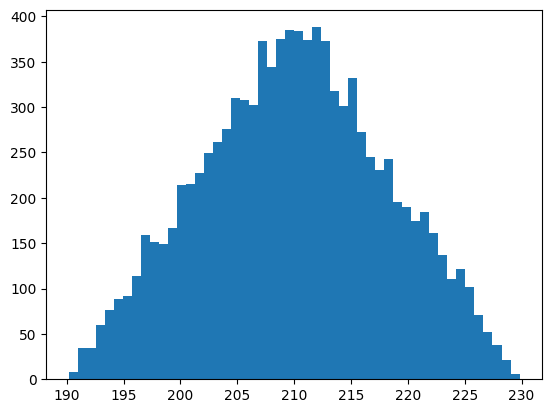

In [ ]:
plt.hist(M, bins=50)

**SIMULACION:**

In [ ]:
n_simulaciones = 100000
capacidad_maxima = 1000
contador_excesos = 0
sumas_pesos = []

**Generacion de las 5 variables aleatorias**

*OBS: El teorema establece que si sumas un conjunto de variables aleatorias independientes (en este caso, el peso de cada una de las 5 tinas), la suma total ($S$) tenderá a seguir una Distribución Normal (campana de Gauss), sin importar que las variables originales sean triangulares, uniformes o de otro tipo.*

In [ ]:
for _ in range(n_simulaciones):

    viaje = generar_tinas(5)
    S = sum(viaje)
    sumas_pesos.append(S)

    # Verificamos si excede la capacidad
    if S > capacidad_maxima:
        contador_excesos += 1

**CALCULO DE LA PROBABILIDAD**

In [ ]:
probabilidad = contador_excesos / n_simulaciones

print(f"--- Resultados de la Simulación TIBASA ---")
print(f"Probabilidad de exceder 1000kg: {probabilidad:.4f}")

--- Resultados de la Simulación TIBASA ---
Probabilidad de exceder 1000kg: 0.9972


*Se concluye que la probabilidad de que el peso de las tinas exceda la capacidad del camión es de $0.99$*

**GRAFICAS PARA VERIFICAR**

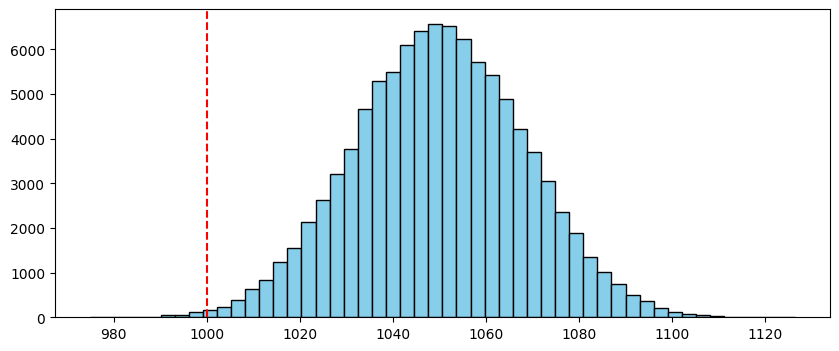

In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(sumas_pesos, bins=50, color='skyblue', edgecolor='black')
plt.axvline(capacidad_maxima, color='red', linestyle='--', label='Capacidad 1000kg')
plt.show()

**MEDIA**

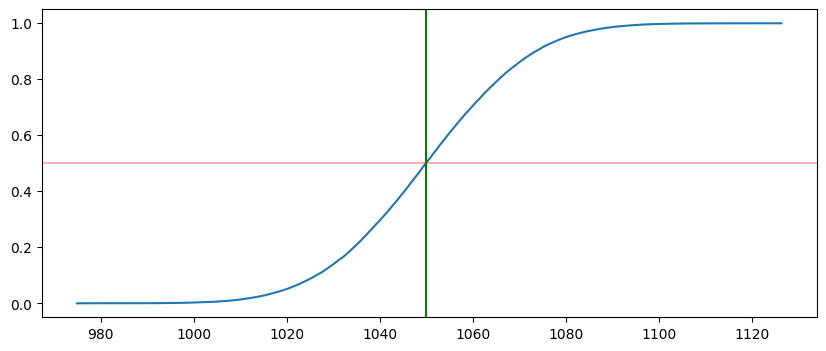

In [ ]:
def cdf(datos):
    n = len(datos)
    x = np.sort(datos)
    y = np.arange(0, n) / n
    return x, y

x_sumas, y_sumas = cdf(sumas_pesos)
media = np.mean(sumas_pesos)

plt.figure(figsize=(10, 4))
plt.step(x_sumas, y_sumas)
plt.axvline(x=media, color='green', label=f'Media: {media:.2f}kg')
plt.axhline(y=0.5, color='red', alpha=0.3)
plt.show()

**Solucion Analitica**

Tenemos la densidad triangular:\
$a=190$\
$b=230$ (max)\
$c=210$


De lo anterior:

**Paso 1: Funcion de densidad**

$$f(x)=
\begin{cases}
\frac{x-190}{800} & 190 \le x \le 210 \\
\frac{230-x}{800} & 210 < x \le 230 \\
\end{cases}$$

**Paso 2: Funcion de distribucion acumulada**

Calculamos F(x)

Por definición:


$F(x)=\int_{-\infty}^{x} f(t)\,dt$





Caso 1: $190 \le x \le 210$

$F(x)=\int_{190}^{x} \frac{t-190}{800} dt$


$F(x)=\frac{1}{800}\int_{190}^{x} (t-190)\,dt$

$F(x)=\frac{1}{800}\cdot \frac{(x-190)^2}{2}$

$F(x)=\frac{(x-190)^2}{1600}$




**Caso 2:**\
$210 < x \le 230$

$F(x)=F(210) + \int_{210}^{x} \frac{230-t}{800} dt$

$F(210)=\frac{(210-190)^2}{1600}=\frac{400}{1600}=\frac{1}{4}$

$F(x)=\frac{1}{4} + \frac{1}{800}\int_{210}^{x} (230-t)\,dt$


Esto es:
$$F(x)=
\frac{1}{4} + \frac{1}{800}(
-\frac{(230-x)^2}{2} + \frac{(20)^2}{2})
$$

Resolviendo la integral, obtenemos:\
$F(x)=1 - \frac{(230-x)^2}{1600}$


**Podemos concluir que**

$$F(x)=
\begin{cases}
\frac{(x-190)^2}{1600} & 190 \le x \le 210 \\
1 - \frac{(230-x)^2}{1600} & 210 < x \le 230 \\
\end{cases}$$

**PASO 3: Transformada Inversa**

Sea $R \sim U(0,1)$.\

**CASO 1:**   $0 \le R \le \frac{1}{2}$\
Tenemos:

$R = \frac{(x-190)^2}{1600}$\
Asi\
$x-190 = \sqrt{1600R}$\
Esto es:\
$x = 190 + 40\sqrt{R}$


**CASO 2:** $\frac{1}{2} < R \le 1$\
De lo anterior:\
$R = 1 - \frac{(230-x)^2}{1600}$\
$(230-x)^2 = 1600(1-R)$\
$x = 230 - 40\sqrt{1-R}$

**Generador final:**


$$X= \cases{190 + \sqrt{40R}&si $0 \leq R \leq \frac{1}{2}$,\cr 230-\sqrt{40(1-R)}&si $\frac{1}{2} < R \leq 1$}$$

**Finalmente hagamos la aproximacion analitica:**

**Media :**
Por definicion:\
$\mu = \frac{a+b+c}{3}$\
En este caso:\
$\mu = 210$

**Varianza:**
$\sigma^2 =
\frac{
190^2 + 210^2 + 230^2 - (190)(210) - (190)(230) - (210)(230)
}{18} = 66.67$\
Esto es\
$\sigma = \sqrt{66.67} \approx 8.165$

Por otro lado:

$E[S] = 5\mu = 5(210) = 1050$\
$Var(S) = 5\sigma^2 = 5(66.67) = 333.33$\

$\sigma_S = \sqrt{333.33} \approx 18.26$

**Aplicando el TEOREMA CENTRAL DEL LIMITE**\
$S \approx N(1050,\; 333.33)$\

ESTANDARIZANDO:\
$Z = \frac{1000 - 1050}{18.26} = \frac{-50}{18.26} \approx -2.74$


**PROBABILIDAD:**\
$P(S > 1000) = P(Z > -2.74)$\
$= 1 - P(Z \le -2.74)$\
$= P(Z < 2.74)$\
$P(Z < 2.74) \approx 0.997$

Por lo tanto:\
$\boxed{P(S > 1000) \approx 0.997}$

El valor esperado de la suma es $1050$, el cual excede la capacidad del camión (1000 kg).
Dado que la desviación estándar es relativamente pequeña, la probabilidad de exceder la capacidad es muy alta, cercana a 1.


**Las soluciones ANALITICA  y de SIMULACION coinciden**